# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
SEED = 1
SIZE = 100
HIDDEN_LAYER = 100
LEARNING_RATE = 0.1
EPOCHS = 10

np.random.seed(SEED)

# Funcs

In [154]:
def eq(x):
    return x


def hs(x):
    return np.where(x < 0, 0, 1)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def th(x):
    return np.tanh(x)


def arctg(x):
    return np.arctan(x)


def neuron_output(X, w, b, func):
    z = np.dot(X, w) + b
    return func(z)


def plot_decision_boundary(w, b, name):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1

    x_plot = np.array([x_min, x_max])
    y_plot = -(w[0] * x_plot + b) / w[1]

    plt.plot(x_plot, y_plot, 'k--', linewidth=2, label='Граница решений')

    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(f'Граница решений однослойного перцептрона {name}')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()

# Dataset

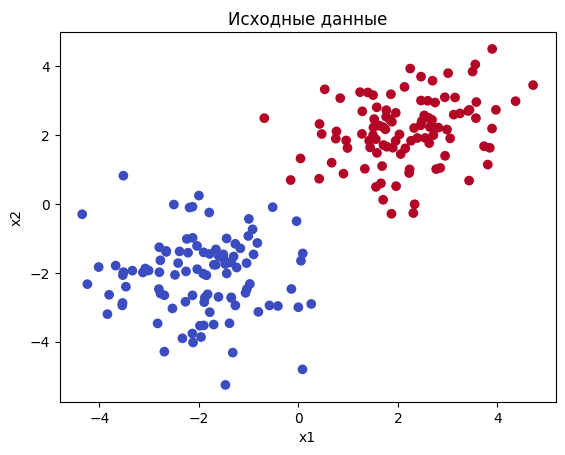

In [115]:
class_1 = np.random.randn(SIZE, 2) + np.array([-2, -2])
class_2 = np.random.randn(SIZE, 2) + np.array([2, 2])

X = np.vstack((class_1, class_2))
y = np.array([0] * SIZE + [1] * SIZE)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

# Perceptron

## Without Activation

In [164]:
losses = []
w = np.random.randn(2)
b = 0.0

for epoch in range(EPOCHS):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        y_pred = 1 if z >= 0 else 0
        error = y[i] - y_pred
        w += LEARNING_RATE * error * X[i]
        b += LEARNING_RATE * error
    preds = np.array([1 if np.dot(x, w) + b >= 0 else 0 for x in X])
    acc = (preds == y).mean()
    losses.append(1 - acc)
    print(f"Эпоха {epoch + 1}/{EPOCHS} — точность: {acc:.4f}")

Эпоха 1/10 — точность: 1.0000
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 1.0000
Эпоха 4/10 — точность: 1.0000
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 1.0000
Эпоха 8/10 — точность: 1.0000
Эпоха 9/10 — точность: 1.0000
Эпоха 10/10 — точность: 1.0000


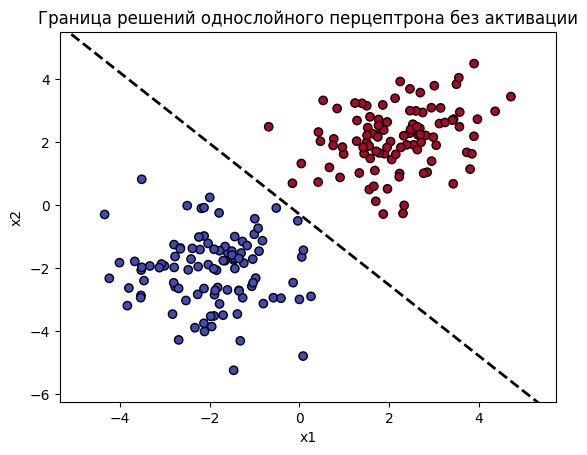

In [165]:
plot_decision_boundary(w, b, "без активации")

## Without HS


In [162]:
losses = []
w = np.random.randn(2)
b = 0.0

for epoch in range(EPOCHS):
    for i in range(len(X)):
        z = hs(np.dot(X[i], w) + b)
        y_pred = int(z)
        error = y[i] - y_pred
        w += LEARNING_RATE * error * X[i]
        b += LEARNING_RATE * error
    preds = np.array([int(hs(np.dot(x, w) + b)) for x in X])
    acc = (preds == y).mean()
    losses.append(1 - acc)
    print(f"Эпоха {epoch + 1}/{EPOCHS} — точность: {acc:.4f}")

Эпоха 1/10 — точность: 1.0000
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 1.0000
Эпоха 4/10 — точность: 1.0000
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 1.0000
Эпоха 8/10 — точность: 1.0000
Эпоха 9/10 — точность: 1.0000
Эпоха 10/10 — точность: 1.0000


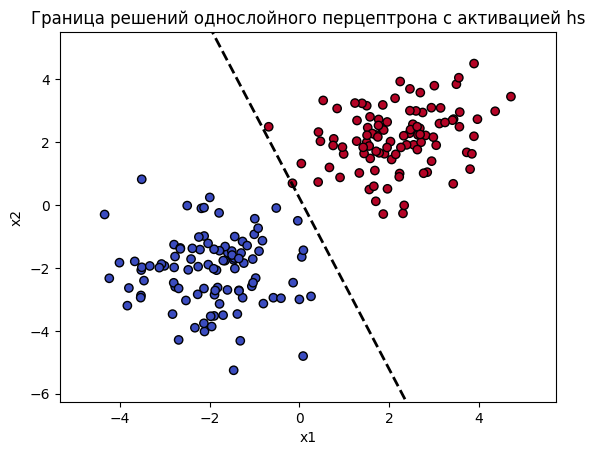

In [163]:
plot_decision_boundary(w, b, "с активацией hs")

## With Sigmoid

In [166]:
losses = []
w = np.random.randn(2)
b = 0.0

for epoch in range(EPOCHS):
    for i in range(len(X)):
        z = sigmoid(np.dot(X[i], w) + b)
        y_pred = 1 if z >= 0.5 else 0

        error = y[i] - y_pred
        w += LEARNING_RATE * error * X[i]
        b += LEARNING_RATE * error

    preds = np.array([1 if sigmoid(np.dot(x, w) + b) >= 0.5 else 0 for x in X])
    acc = (preds == y).mean()
    losses.append(1 - acc)
    print(f"Эпоха {epoch + 1}/{EPOCHS} — точность: {acc:.4f}")

Эпоха 1/10 — точность: 1.0000
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 1.0000
Эпоха 4/10 — точность: 1.0000
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 1.0000
Эпоха 8/10 — точность: 1.0000
Эпоха 9/10 — точность: 1.0000
Эпоха 10/10 — точность: 1.0000


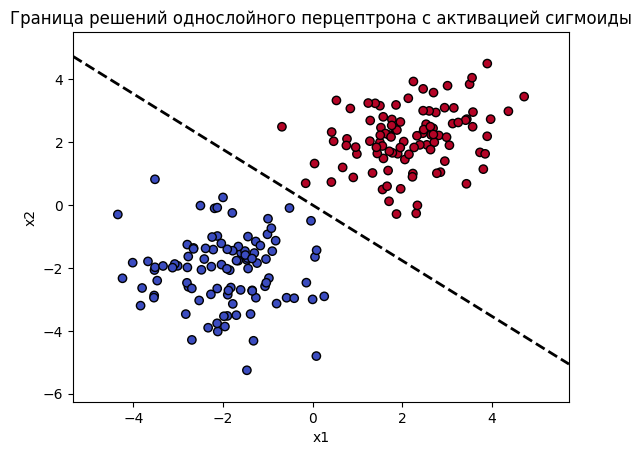

In [167]:
plot_decision_boundary(w, b, "с активацией сигмоиды")

# With Tanh

In [168]:
losses = []
w = np.random.randn(2)
b = 0.0

for epoch in range(EPOCHS):
    for i in range(len(X)):
        z = th(np.dot(X[i], w) + b)
        y_pred = 1 if z >= 0 else 0
        error = y[i] - y_pred
        w += LEARNING_RATE * error * X[i]
        b += LEARNING_RATE * error
    preds = np.array([1 if th(np.dot(x, w) + b) >= 0 else 0 for x in X])
    acc = (preds == y).mean()
    losses.append(1 - acc)
    print(f"Эпоха {epoch + 1}/{EPOCHS} — точность: {acc:.4f}")

Эпоха 1/10 — точность: 1.0000
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 1.0000
Эпоха 4/10 — точность: 1.0000
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 1.0000
Эпоха 8/10 — точность: 1.0000
Эпоха 9/10 — точность: 1.0000
Эпоха 10/10 — точность: 1.0000


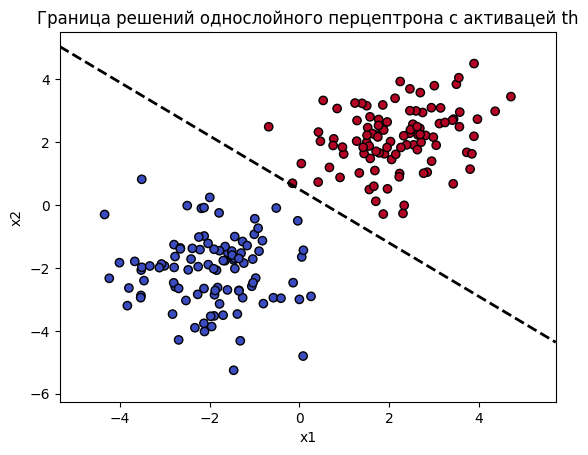

In [169]:
plot_decision_boundary(w, b, "с активацей th")

## With Arctan

In [170]:
losses = []
w = np.random.randn(2)
b = 0.0

for epoch in range(EPOCHS):
    for i in range(len(X)):
        z = arctg(np.dot(X[i], w) + b)
        y_pred = 1 if z >= 0 else 0
        error = y[i] - y_pred
        w += LEARNING_RATE * error * X[i]
        b += LEARNING_RATE * error
    preds = np.array([1 if arctg(np.dot(x, w) + b) >= 0 else 0 for x in X])
    acc = (preds == y).mean()
    losses.append(1 - acc)
    print(f"Эпоха {epoch + 1}/{EPOCHS} — точность: {acc:.4f}")

Эпоха 1/10 — точность: 1.0000
Эпоха 2/10 — точность: 1.0000
Эпоха 3/10 — точность: 1.0000
Эпоха 4/10 — точность: 1.0000
Эпоха 5/10 — точность: 1.0000
Эпоха 6/10 — точность: 1.0000
Эпоха 7/10 — точность: 1.0000
Эпоха 8/10 — точность: 1.0000
Эпоха 9/10 — точность: 1.0000
Эпоха 10/10 — точность: 1.0000


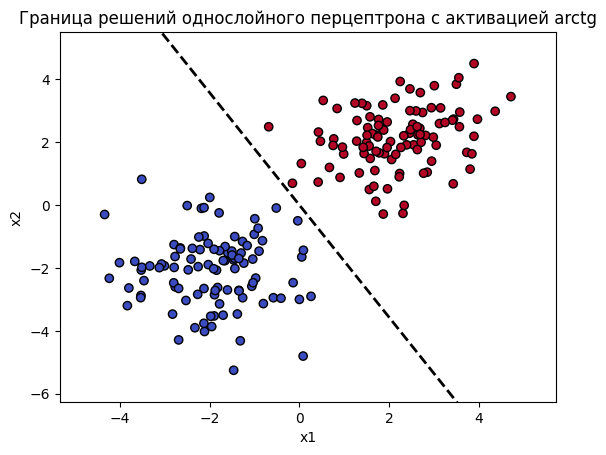

In [171]:
plot_decision_boundary(w, b, "с активацией arctg")

## Разница функций активации

Однослойный перцептрон всегда выдает прямую линию. Таким образом функция активации влияет лишь на диапазон возвращающих значений. Для Сигмоиды - от 0 до 1, в тангенсе от -1 до 1, а в тождественном отображении - (-беск; беск).

## Что делает функция активации в искусственном нейроне2. Чем отличается искусственный нейрон от однослойного перцептрона?



Функция активация нормирует выход нейрона в какой то промежуток значений. Но в общем функция активации позволяет прийти к нелинейности, что позволяет саппроксимировать любую функцию. Искусственный нейрон - математическая единица. Однослойный перцептрон - это уже архитектура, которая строится из нейронов. В ней также вход, сразу соединен с выходом. Но в зависимости от задачи - количество выходных нейронов может меняться. В нашем случае (бинарная классификация) - один нейрон на выходе. Следовательно, в нашей задаче различие лишь смысловое, а по факту ее нет.

## Какое правило используется для обучения перцептрона?

Корректировка весов, пропорционально ошибке.

## Почему однослойный перцептрон не может решить задачу XOR?

Так как однослойный перцептрон решает линейно разделимые задачи, то он не может разделить одной прямой точки, для разделения которых нужна нелинейность

## Что произойдет, если изменить функцию активации с сигмоиды на ReLU?

Граница решений также останется линейной, ведь ReLu = max(0, x). Перцептрон все также не сможет решать нелинейные задачи. Изменится лишь диапазон значений [0, +inf)